### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

C:\Users\itsme\AppData\Local\Temp\ipykernel_19776\1871147362.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [2]:
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from langchain_core.tools import tool

@tool
def arxiv_tool(query: str) -> str:
    """Search arXiv for research papers and return titles and summaries."""
    # 1. Encode query and construct HTTPS request
    encoded_query = urllib.parse.quote(query)
    url = f"https://export.arxiv.org/api/query?search_query=all:{encoded_query}&start=0&max_results=2"
    
    headers = {"User-Agent": "MyRAGApp/1.0"}
    req = urllib.request.Request(url, headers=headers)
    
    try:
        with urllib.request.urlopen(req) as response:
            xml_data = response.read()
            
        # 2. Parse XML response
        root = ET.fromstring(xml_data)
        namespace = {"atom": "http://www.w3.org/2005/Atom"}
        
        results = []
        for entry in root.findall("atom:entry", namespace):
            title = entry.find("atom:title", namespace).text.strip().replace("\n", " ")
            summary = entry.find("atom:summary", namespace).text.strip().replace("\n", " ")
            results.append(f"Title: {title}\nSummary: {summary[:500]}...")
            
        return "\n\n".join(results) if results else "No results found."
        
    except Exception as e:
        return f"Error fetching from arXiv: {e}"

# Test the custom tool directly
response = arxiv_tool.invoke("Attention Is All You Need")
print(response)

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a...

Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponentia

In [3]:
import wikipedia
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

# 1. Set custom User-Agent to prevent Wikipedia API blocks
wikipedia.set_user_agent("RAGBootcampApp/1.0 (jahidhasan@example.com)")

# 2. Initialize API Wrapper and Tool
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

# 3. Invoke cleanly!
response = wiki.invoke("What is machine learning")
print(response)

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent-Project"

Read : https://www.ibm.com/think/topics/react-agent <b>


In [7]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv_tool,wiki,add,multiply,divide]

In [8]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\itsme\AppData\Local\Temp\ipykernel_19776\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'Weekly AI News: 3 March 2025 - AIforBusiness.net',
  'url': 'https://www.youtube.com/watch?v=kw21NJ7YmZM',
  'content': "This week’s AI update explores some of the most impactful developments shaping technology and society. OpenAI has unveiled GPT-4.5, a cutting-edge model with enhanced intuition and emotional intelligence. While its capabilities push AI closer to human-like perception, its high computational demands raise concerns about accessibility, particularly for smaller businesses.\nMeanwhile, AI is revolutionising taxation. The IMF reports that governments are leveraging AI to detect fraud and streamline audits, while taxpayers benefit from automated filing systems. However, privacy and fairness remain key concerns. [...] businesses and individuals can now use Aid driven tools to automate tax filings reducing errors and improving accuracy the challenge privacy concerns and ensuring that AI driven tax enforcement remains fair and [Music] unbiased Ai and the ghosts in

In [10]:
### Combine all the tools in the list

tools=[arxiv_tool,wiki,tavily,add,divide,multiply]

In [11]:
## Initialize my LLM model

from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o-mini-2024-07-18")

llm_with_tools=llm.bind_tools(tools)

In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 258, 'total_tokens': 278, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c73dd82b09', 'id': 'chatcmpl-E7MtyEA4CzE6NwmS1wCOqRWmLLFOp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb3a0-017a-72b0-8308-3725f61e69d2-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'call_UyEl3fYB2Tzju0LalaWEpyLt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 258, 'output_tokens': 20, 'total_tokens': 278, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

In [13]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'call_BaxLjwyvyt1oOGLIAaI7tjPG',
  'type': 'tool_call'}]

In [14]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

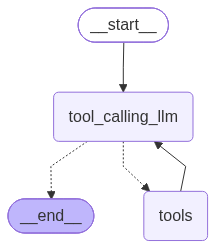

In [15]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for July 30 2026,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for July 30 2026,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_bm2gf22ezqARtczkoCpUbWfy)
 Call ID: call_bm2gf22ezqARtczkoCpUbWfy
  Args:
    query: AI news July 30 2026
  add (call_NEnzmTw2xgVffAkWIEnZFEPF)
 Call ID: call_NEnzmTw2xgVffAkWIEnZFEPF
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "DX Today AI Daily Brief - Thursday, July 30, 2026", "url": "https://www.youtube.com/watch?v=p1CfS_QRKTo", "content": "Microsoft closes fiscal 2026 with Azure past $100 billion and Microsoft 365 Copilot beyond 30 million paid seats, while Meta lifts its capital spending floor to $130 billion as costs climb 55 percent. Samsung posts record sales and an operating

In [17]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_Kdb5D6nGdVVLtGW16ts2p2WO)
 Call ID: call_Kdb5D6nGdVVLtGW16ts2p2WO
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
================================== Ai Message ==================================


### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (call_KSMgbvdHLgWrsYeZqgdrWjKf)
 Call ID: call_KSMgbvdHLgWrsYeZqgdrWjKf
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

5 plus 8 is 13.


In [19]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

Could you please provide the number you would like to divide by 5?


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!


In [21]:
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o-mini-2024-07-18")

llm_with_tools=llm.bind_tools(tools)


In [22]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

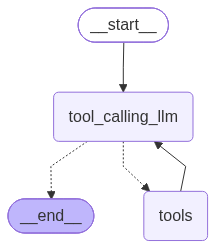

In [23]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [24]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_YtRE94F5DQ7EHkgUiWBqpDHL)
 Call ID: call_YtRE94F5DQ7EHkgUiWBqpDHL
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.


In [25]:
messages = [HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_YtRE94F5DQ7EHkgUiWBqpDHL)
 Call ID: call_YtRE94F5DQ7EHkgUiWBqpDHL
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_sPGFMmLL8qqRAzg6zBWKjg7p)
 Call ID: call_sPGFMmLL8qqRAzg6zBWKjg7p
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 2

In [26]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_YtRE94F5DQ7EHkgUiWBqpDHL)
 Call ID: call_YtRE94F5DQ7EHkgUiWBqpDHL
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_sPGFMmLL8qqRAzg6zBWKjg7p)
 Call ID: call_sPGFMmLL8qqRAzg6zBWKjg7p
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 2